In [1]:
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
import numpy as np

key = random.key(0)

Creating ilustration: FW_init


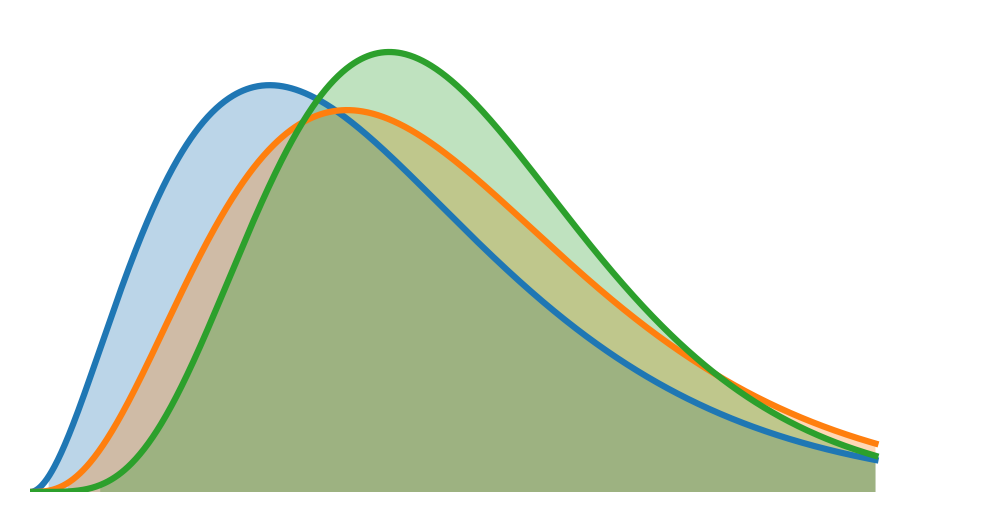

Creating ilustration: FW_state


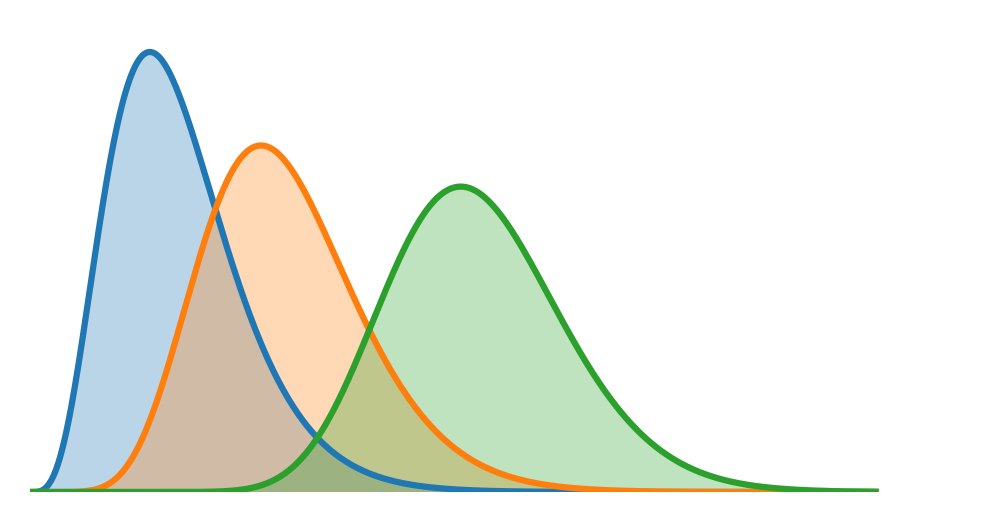

Creating ilustration: FW_sampled


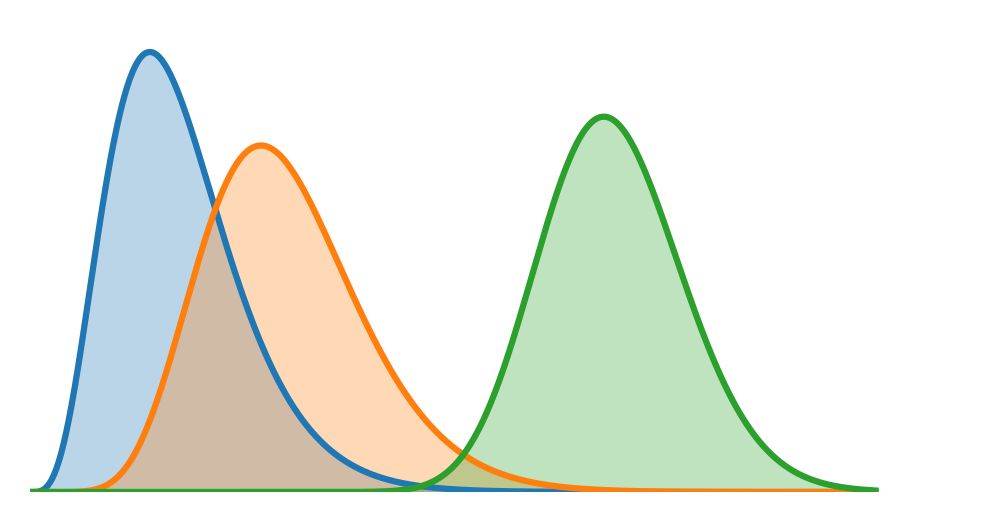

Creating ilustration: FW_pruned


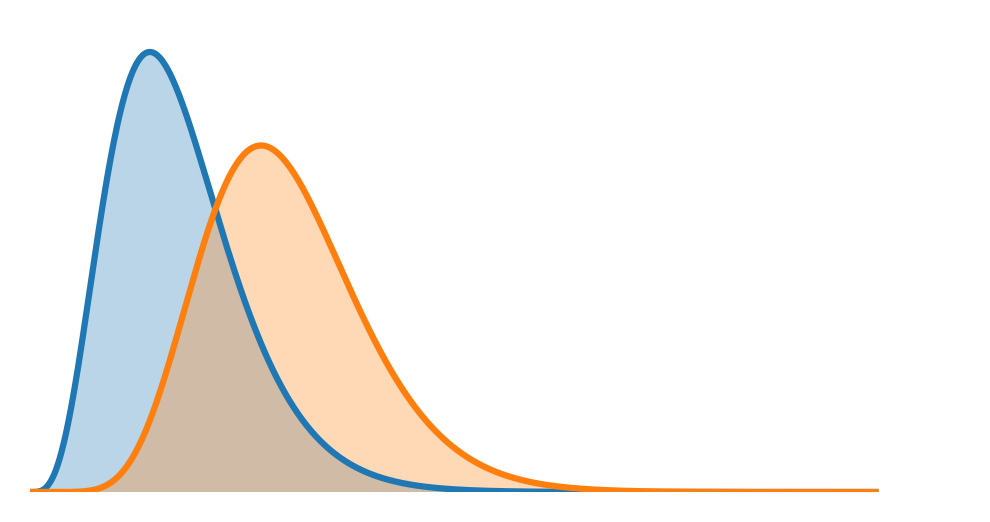

Creating ilustration: FW_mutated


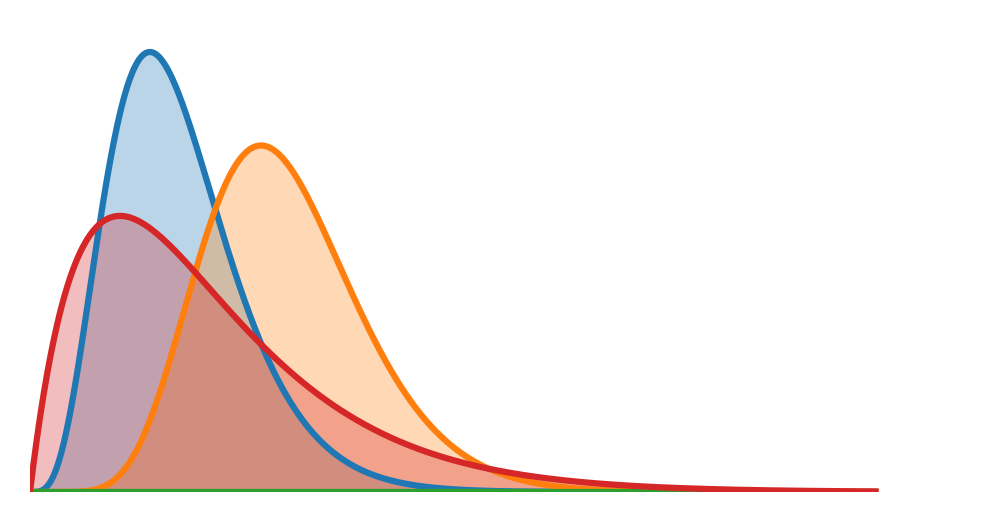

In [3]:
alpha1, beta1 = np.array([
    [3, 1500],
    [4, 1700],
    [6, 2500],
]).T
alpha2, beta2 = np.array([
    [5, 6000],
    [10, 7000],
    [25, 10000],
]).T
alpha3, beta3 = np.array([
    [5, 6000],
    [10, 7000],
    [65, 20000],
]).T
alpha4, beta4 = np.array([
    [5, 6000],
    [10, 7000],
    # [65, 20000],
]).T
alpha5, beta5 = np.array([
    [5, 6000],
    [10, 7000],
    [6500, 20000],
    [2, 2000],
]).T
for alpha, beta, name in zip(
    [alpha1, alpha2, alpha3, alpha4, alpha5],
    [beta1, beta2, beta3, beta4, beta5],
    ['FW_init', 'FW_state', 'FW_sampled', 'FW_pruned', 'FW_mutated'],
):
    print(f"Creating ilustration: {name}")
    ps = beta / (alpha + beta)
    var = (alpha * beta) / ((alpha + beta) ** 2 * (alpha + beta + 1))

    conf = 0.999
    lb = beta_dist.ppf((1 - conf) / 2, alpha, beta)
    ub = beta_dist.ppf(1 - (1 - conf) / 2, alpha, beta)

    plt.figure(figsize=(4, 2), dpi=300)
    x = jnp.linspace(0, .0047, 1000)
    # x = jnp.linspace(max(0, lb.min()), min(1, ub.max()), 200)
    for i in range(len(ps)):
        plt.plot(x, beta_dist.pdf(x, alpha[i], beta[i]), label=f'p={ps[i]:.2%}, Var={var[i]:.2e}')
        plt.fill_between(
            x,
            beta_dist.pdf(x, alpha[i], beta[i]),
            where=(x >= lb[i]) & (x <= ub[i]),
            alpha=0.3,
        )

    # plt.legend()
    # plt.title('Posterior distributions of p')
    # plt.xlabel('Success Probability')
    # plt.ylabel('Density')
    # xticks = plt.xticks()[0]
    # xtick_labels = [f'{x:.2%}' for x in xticks]
    # plt.xticks(xticks, xtick_labels)

    plt.xticks([])
    plt.yticks([])
    # plt.xlabel('Logical Error Rate')
    # plt.ylabel('Density')
    # plt.title('Posterior Distributions', y=.85)
    plt.xlim(x.min(), x.max()*1.1)
    plt.ylim(0, None)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # ax.annotate('', xy=(0.00485, 0), xytext=(-.00005, 0),
    #             arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))
    # ax.annotate('', xy=(0, ax.get_ylim()[1]), xytext=(0, -20),
    #             arrowprops=dict(arrowstyle='->', lw=1.5, color='black'))

    plt.savefig(name+'.pdf', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()